## 1. Load the Dataset

We will load the `student-mat.csv` file into a pandas DataFrame and display its first few rows and information to get an initial understanding of the data structure and types.

In [2]:
import pandas as pd

# Load the dataset with semicolon delimiter
df = pd.read_csv('/content/student-mat.csv', sep=';')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the DataFrame
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    objec

## 2. Data Preprocessing and Feature Selection

In this section, we will preprocess the dataset. This involves handling any missing values, encoding categorical variables, and selecting the features (X) and the target variable (y) for our Linear Regression model.

In [3]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include='object').columns

print("\nUnique values for each categorical column:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Missing values in each column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Unique values for each categorical column:
school: ['GP' 'MS']
sex: ['F' 'M']
address: ['U' 'R']
famsize: ['GT3' 'LE3']
Pstatus: ['A' 'T']
Mjob: ['at_home' 'health' 'other' 'services' 'teacher']
Fjob: ['teacher' 'other' 'services' 'health' 'at_home']
reason: ['course' 'other' 'home' 'reputation']
guardian: ['mother' 'father' 'other']
schoolsup: ['yes' 'no']
famsup: ['no' 'yes']
paid: ['no' 'yes']
activities: ['no' 'yes']
nu

### 2.1 Encode Categorical Variables

We will use one-hot encoding to convert all categorical features into numerical format. This is necessary for Linear Regression models.

In [4]:
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
display(df_encoded.head())
print(f"New shape of the DataFrame: {df_encoded.shape}")

DataFrame after one-hot encoding:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


New shape of the DataFrame: (395, 42)


### 2.2 Feature Selection and Data Splitting

We will select 'G3' as the target variable ($y$) and all other columns as features ($X$). Then, we'll split the data into training and testing sets to evaluate our model's performance.

In [5]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('G3', axis=1)
y = df_encoded['G3']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (316, 41)
Shape of X_test: (79, 41)
Shape of y_train: (316,)
Shape of y_test: (79,)


## 3. Implement Linear Regression using Gradient Descent

We will implement Linear Regression from scratch using Gradient Descent. This involves defining a cost function (Mean Squared Error) and a gradient descent function to iteratively update the model's parameters (weights and bias) to minimize the cost.

In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the training and testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert DataFrames to NumPy arrays for easier mathematical operations
X_train_np = X_train_scaled
y_train_np = y_train.values.reshape(-1, 1) # Reshape y to be a column vector
X_test_np = X_test_scaled
y_test_np = y_test.values.reshape(-1, 1)

# Add a bias term (intercept) to X
X_train_b = np.c_[np.ones((X_train_np.shape[0], 1)), X_train_np]
X_test_b = np.c_[np.ones((X_test_np.shape[0], 1)), X_test_np]

# Cost Function (Mean Squared Error)
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/(2*m)) * np.sum(np.square(predictions - y))
    return cost

# Gradient Descent Function
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        gradient = (1/m) * X.T.dot(errors)
        theta = theta - learning_rate * gradient
        cost_history[i] = compute_cost(X, y, theta)

    return theta, cost_history

# Initialize parameters
# (Number of features + 1 for the bias term)
n_features = X_train_b.shape[1]
theta = np.zeros((n_features, 1))

# Hyperparameters
learning_rate = 0.01
iterations = 1000

print(f"Initial cost: {compute_cost(X_train_b, y_train_np, theta):.4f}")

# Train the model
theta_final, cost_history = gradient_descent(X_train_b, y_train_np, theta, learning_rate, iterations)

print(f"Optimized parameters (theta):")
print(theta_final)
print(f"Final cost: {cost_history[-1]:.4f}")

Initial cost: 63.8149
Optimized parameters (theta):
[[ 1.03255036e+01]
 [-1.71252446e-01]
 [ 9.64121900e-02]
 [-1.92324640e-01]
 [ 2.55705649e-02]
 [-3.69396876e-02]
 [-1.86206569e-01]
 [ 2.78110587e-01]
 [-3.56574907e-02]
 [ 1.93598520e-01]
 [-1.58820855e-01]
 [ 8.81026754e-02]
 [ 5.59250962e-02]
 [ 4.51386572e-01]
 [ 1.07384353e+00]
 [ 3.22166829e+00]
 [ 4.25509585e-02]
 [ 1.69428991e-01]
 [ 4.39978309e-02]
 [-7.98264572e-03]
 [-6.71143968e-02]
 [-1.19779366e-01]
 [-6.84484148e-02]
 [-1.63461071e-02]
 [ 4.69643994e-02]
 [ 1.11541670e-01]
 [ 1.58301036e-01]
 [-8.14903786e-02]
 [-3.25676592e-02]
 [-2.56036783e-01]
 [ 1.23640329e-01]
 [-9.15340193e-02]
 [ 4.18364674e-02]
 [-4.75220750e-02]
 [ 3.29193325e-01]
 [ 1.12444283e-01]
 [ 7.14710212e-02]
 [-2.39826622e-01]
 [-9.11387313e-02]
 [ 5.12443714e-02]
 [-5.12469802e-02]
 [-2.17256185e-01]]
Final cost: 1.4302


## 4. Plot Loss vs. Iterations

To analyze the convergence of the Gradient Descent algorithm, we will plot the cost function (MSE) against the number of iterations.

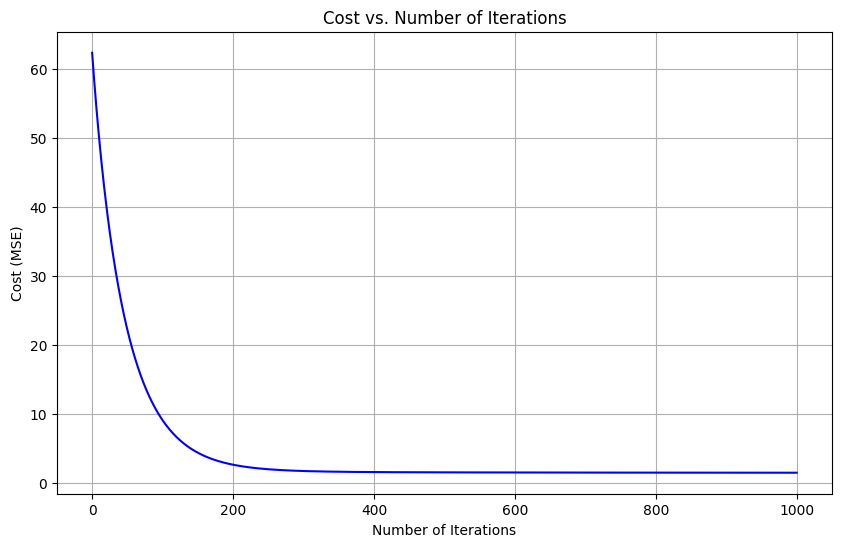

In [10]:
import matplotlib.pyplot as plt

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(iterations), cost_history, color='blue')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Cost vs. Number of Iterations')
plt.grid(True)
plt.show()

## 5. Model Evaluation

Now, we'll evaluate the performance of our Linear Regression model on the test set using the optimized `theta` values. We'll calculate the Mean Squared Error (MSE) and the R-squared score to assess how well our model performs.

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
predictions = X_test_b.dot(theta_final)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test_np, predictions)

# Calculate R-squared score
r2 = r2_score(y_test_np, predictions)

print(f"Mean Squared Error on Test Set: {mse:.4f}")
print(f"R-squared Score on Test Set: {r2:.4f}")

Mean Squared Error on Test Set: 5.6936
R-squared Score on Test Set: 0.7223


In [13]:
from sklearn.metrics import mean_absolute_error

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_np, predictions)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse) # We already have mse from the previous step

print(f"Mean Absolute Error on Test Set: {mae:.4f}")
print(f"Root Mean Squared Error on Test Set: {rmse:.4f}")

Mean Absolute Error on Test Set: 1.6700
Root Mean Squared Error on Test Set: 2.3861


### Visualize Predictions vs. Actual Values

To further understand the model's performance, we can visualize the predicted `G3` values against the actual `G3` values for the test set.

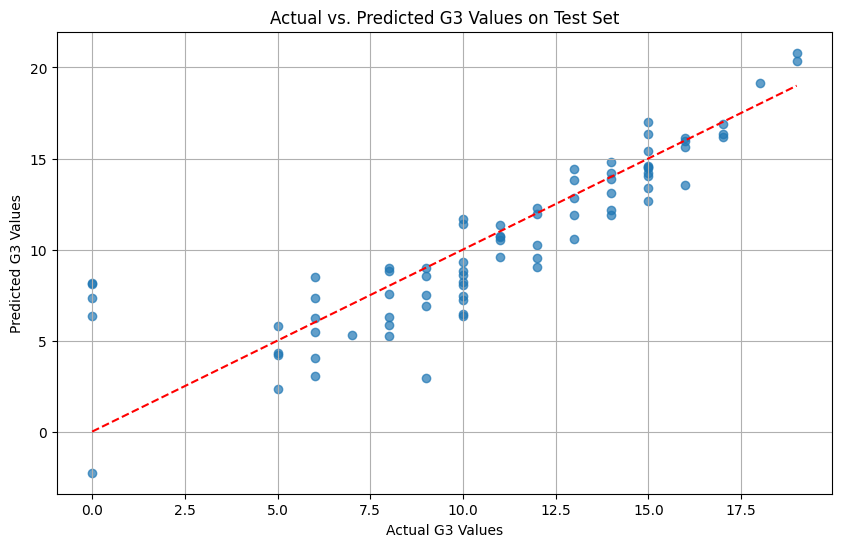

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_np, predictions, alpha=0.7)
plt.xlabel('Actual G3 Values')
plt.ylabel('Predicted G3 Values')
plt.title('Actual vs. Predicted G3 Values on Test Set')
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--') # Perfect prediction line
plt.grid(True)
plt.show()